# Per Pupil Expenditure vs. Disability Prevalence

Disability Prevalence: https://data.ed.gov/dataset/idea-section-618-lea-part-b-child-count/resources

District Profile Report (for PPE): https://education.ohio.gov/Topics/Finance-and-Funding/School-Payment-Reports/District-Profile-Reports/FY2024-District-Profile-Report

In [3]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

from IDEA_loader import load_IDEA
from DPR_loader import load_DPR

In [4]:
# Just looking at school age children, so removing "Early Childhood"

IDEA_COLS_TO_DROP = [
    'Combined Early Childhood and School Age Total',
    'Early Childhood All Disabilities',
    'Early Childhood Autism',
    'Early Childhood Deaf-blindness',
    'Early Childhood Developmental Delay',
    'Early Childhood Emotional Disturbance',
    'Early Childhood Hearing Impairment',
    'Early Childhood Intellectual Disability',
    'Early Childhood Multiple Disabilities',
    'Early Childhood Orthopedic Impairment',
    'Early Childhood Other Health Impairment',
    'Early Childhood Specific Learning Disability',
    'Early Childhood Speech or Language Impairment',
    'Early Childhood Traumatic Brain Injury',
    'Early Childhood Visual Impairment',
    'Early Childhood Missing',
    
    # gives no information (all 0s)
    'School Age Missing'
]

IDEA_COL_MAPPING = {
    'School Age All Disabilities' : 'All Disabilites',
    'School Age Autism' : 'Autism',
    'School Age Deaf-blindness' : 'Deaf-blindness',
    'School Age Developmental Delay': 'Developmental Delay',
    'School Age Emotional Disturbance': 'Emotional Disturbance',
    'School Age Hearing Impairment' : 'Hearing Impariment',
    'School Age Intellectual Disability' : 'Intellectual Disability',
    'School Age Multiple Disabilities' : 'Multiple Disabilities',
    'School Age Orthopedic Impairment' : 'Orthopedic Impairment',
    'School Age Other Health Impairment' : 'Other Health Impairment',
    'School Age Specific Learning Disability': 'Specific Learning Disability',
    'School Age Speech or Language Impairment' : 'Speech or Language Impairment',
    'School Age Traumatic Brain Injury': 'Traumatic Brain Injury',
    'School Age Visual Impairment': 'Visual Impairment',

    'NCES LEA ID': 'LEAID'
}

DPR_COLS_TO_KEEP = [
    'District',
    'LEAID',
    '% of Students with Disabilities FY23',
    'Administrator Expenditure Per Pupil FY23',
    'Building Operation Expenditure Per Pupil FY23',
    'Instructional Expenditure Per Pupil FY23',
    'Pupil Support Expenditure Per Pupil FY23',
    'Staff Support Expenditure Per Pupil FY23',
    'Total Operating Expenditure Per Pupil FY23'
]

In [5]:
idea_df = load_IDEA('bchildcountdisabilitycategorylea2022-23.csv',
                  skip_rows=4,
                  drop_columns=IDEA_COLS_TO_DROP,
                  column_mappings=IDEA_COL_MAPPING
                  )

dpr_df = load_DPR('FY23-District-Profile-Report-Final-12-14-2023.xlsx',
                  keep_columns=DPR_COLS_TO_KEEP
                  )

In [6]:
# filter to keep just the Ohio school districts
idea_df = idea_df[idea_df['State Name'] == 'OHIO']

# join the DPR and IDEA data on their LEAID
df = pd.merge(dpr_df, idea_df, on='LEAID')

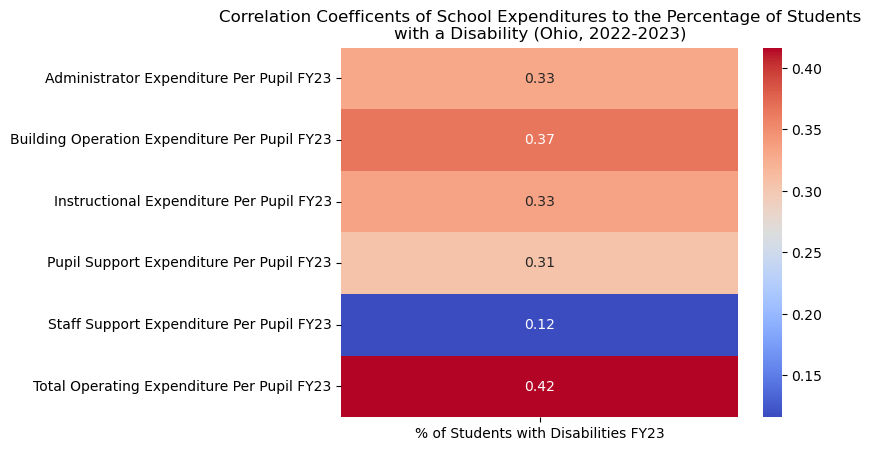

In [7]:
# a correlation heatmap for school expenditure compared to percentage
# of disabled student population

df_select_cols = df[['% of Students with Disabilities FY23',
                    'Administrator Expenditure Per Pupil FY23',
                    'Building Operation Expenditure Per Pupil FY23',
                    'Instructional Expenditure Per Pupil FY23',
                    'Pupil Support Expenditure Per Pupil FY23',
                    'Staff Support Expenditure Per Pupil FY23',
                    'Total Operating Expenditure Per Pupil FY23']]


corr = df_select_cols.corr()[['% of Students with Disabilities FY23']]
corr = corr.drop(index='% of Students with Disabilities FY23')

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Coefficents of School Expenditures to the Percentage of Students\n" \
            "with a Disability (Ohio, 2022-2023)")

plt.show()

In [13]:
subset_df = subset = df[['% of Students with Disabilities FY23', 'Total Operating Expenditure Per Pupil FY23']].dropna()
corr, p_value = pearsonr(subset['% of Students with Disabilities FY23'], subset['Total Operating Expenditure Per Pupil FY23'])
print(corr, p_value)

0.41652897838123404 3.3430757719691597e-25


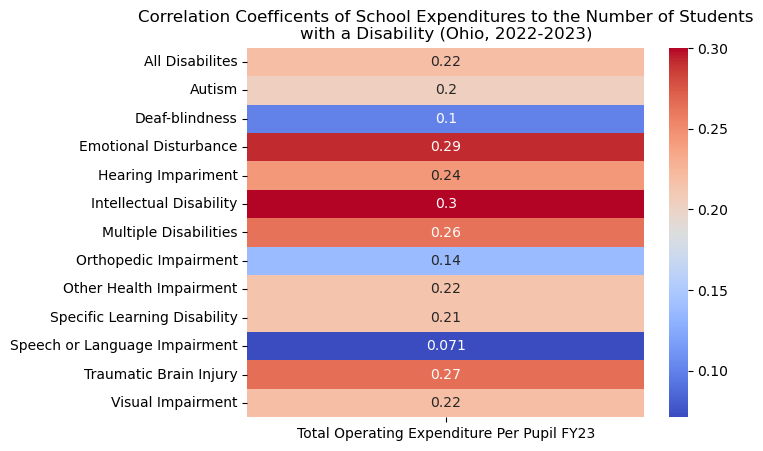

In [9]:
# a correlation heatmap for school expenditure compared to percentage
# of disabled student population

df_select_cols = df[['Total Operating Expenditure Per Pupil FY23',
                    'All Disabilites',
                    'Autism',
                    'Deaf-blindness',
                    #'Developmental Delay', has no data
                    'Emotional Disturbance', 
                    'Hearing Impariment',
                    'Intellectual Disability',
                    'Multiple Disabilities',
                    'Orthopedic Impairment',
                    'Other Health Impairment',
                    'Specific Learning Disability',
                    'Speech or Language Impairment',
                    'Traumatic Brain Injury',
                    'Visual Impairment']]


corr = df_select_cols.corr()[['Total Operating Expenditure Per Pupil FY23']]
corr = corr.drop(index='Total Operating Expenditure Per Pupil FY23')

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Coefficents of School Expenditures to the Number of Students\n" \
            "with a Disability (Ohio, 2022-2023)")

plt.show()